# CNN for MNIST Digit Classification
**CYSE 635 — Module 02 Project** · Erfan Basiri · code for `CYSE635_Module02_Report.pdf`



In [1]:
# ---------------------------------------------------------------------------
# 0. Imports
# ---------------------------------------------------------------------------
import json, math, platform, random, sys, time
from dataclasses import asdict, dataclass, fields, replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from IPython.display import display

In [2]:
# ---------------------------------------------------------------------------
# 0.1 Project code: Global settings & reproducibility
# ---------------------------------------------------------------------------
PROJECT_DIR = Path.cwd()                      # the folder that contains this notebook
DATA_DIR = PROJECT_DIR / "data"

RESULTS_DIR = PROJECT_DIR / "results"     # tables (CSV) and summary.json
RUNS_DIR = RESULTS_DIR / "runs"            # one JSON record per training run
CKPT_DIR = PROJECT_DIR / "checkpoints"     # one weight file per run
FIG_DIR = PROJECT_DIR / "figures"
for _d in (DATA_DIR, RESULTS_DIR, RUNS_DIR, CKPT_DIR, FIG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True         # pick the fastest conv kernels for our fixed input size
torch.backends.cuda.matmul.allow_tf32 = True  # TensorFloat-32 matmuls/convs on Ampere+ GPUs
torch.backends.cudnn.allow_tf32 = True


def seed_everything(seed: int) -> None:
    """Seed every random number generator we use (Python, NumPy, PyTorch CPU + CUDA)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
# ---------------------------------------------------------------------------
# 0.2 Project code: Data: loading, splitting, normalization, augmentation
# ---------------------------------------------------------------------------
VAL_SIZE = 5_000        # held-out validation images carved from the 60k training set
SPLIT_SEED = 42         # fixed so that every run sees exactly the same split
TRAIN_SUBSET = 10_000   # fixed subset of training images used to measure "clean" train loss
MNIST_MEAN, MNIST_STD = 0.1307, 0.3081  # per-pixel statistics of the MNIST training set

_DATA = None  # per-process cache so the data is only loaded/moved to the GPU once


def load_data(device=DEVICE):
    """Download MNIST (if needed), make a stratified train/validation split and
    move every tensor to `device`.

    Images are converted exactly like `transforms.ToTensor()` would do it:
    uint8 in [0, 255] -> float32 in [0, 1] with shape (N, 1, 28, 28).
    Standardization with (MNIST_MEAN, MNIST_STD) happens *inside* the model
    (see `Standardize`), so augmentations can work in pixel space.

    Because the whole dataset is only ~200 MB it is kept resident on the GPU,
    which removes the CPU->GPU copy that normally dominates MNIST training time.
    """
    global _DATA
    if _DATA is not None:
        return _DATA
    from sklearn.model_selection import train_test_split

    train = torchvision.datasets.MNIST(DATA_DIR, train=True, download=True)
    test = torchvision.datasets.MNIST(DATA_DIR, train=False, download=True)
    x_all = train.data.float().div_(255.0).unsqueeze(1)
    y_all = train.targets.clone()
    x_test = test.data.float().div_(255.0).unsqueeze(1)
    y_test = test.targets.clone()

    # Stratified split keeps the 10 classes in the same proportion in both parts.
    idx_tr, idx_val = train_test_split(
        np.arange(len(y_all)), test_size=VAL_SIZE, stratify=y_all.numpy(), random_state=SPLIT_SEED)
    rng = np.random.RandomState(SPLIT_SEED)
    idx_sub = rng.choice(len(idx_tr), TRAIN_SUBSET, replace=False)

    x_tr, y_tr = x_all[idx_tr], y_all[idx_tr]
    _DATA = {
        "x_train": x_tr.to(device), "y_train": y_tr.to(device),
        "x_val": x_all[idx_val].to(device), "y_val": y_all[idx_val].to(device),
        "x_test": x_test.to(device), "y_test": y_test.to(device),
        "x_train_sub": x_tr[idx_sub].to(device), "y_train_sub": y_tr[idx_sub].to(device),
        "idx_train": idx_tr, "idx_val": idx_val,
    }
    return _DATA


def affine(x, angle_deg, scale=1.0, tx_px=0.0, ty_px=0.0):
    """Apply a (per-image) rotation / isotropic scale / translation to a batch.

    All arguments may be scalars or tensors of shape (N,). Works on the GPU with
    `affine_grid` + `grid_sample` (bilinear), padding with 0 = black background.
    """
    n = x.size(0)
    as_t = lambda v: torch.as_tensor(v, dtype=x.dtype, device=x.device).expand(n)
    a, s = torch.deg2rad(as_t(angle_deg)), as_t(scale)
    # pixels -> normalized [-1, 1] coordinates (28 px span a width of 2)
    tx, ty = as_t(tx_px) * 2 / x.size(-1), as_t(ty_px) * 2 / x.size(-2)
    cos, sin = torch.cos(a) / s, torch.sin(a) / s
    # theta maps *output* coordinates to *input* sampling locations
    theta = torch.stack([torch.stack([cos, -sin, tx], 1), torch.stack([sin, cos, ty], 1)], 1)
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    return F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)


# Augmentation strength (chosen to stay label-preserving: a 6 rotated by 180 deg would become a 9!)
AUG_ROT_DEG, AUG_SCALE, AUG_SHIFT_PX = 10.0, 0.10, 2.0


def random_augment(x):
    """Random affine augmentation, one independent transform per image:
    rotation U(-10, 10) deg, scale U(0.9, 1.1), translation U(-2, 2) px in x and y."""
    n = x.size(0)
    u = lambda: torch.rand(n, device=x.device) * 2 - 1  # U(-1, 1)
    return affine(x, AUG_ROT_DEG * u(), 1 + AUG_SCALE * u(), AUG_SHIFT_PX * u(), AUG_SHIFT_PX * u())


def iterate_minibatches(x, y, batch_size, shuffle=True):
    """Minimal GPU 'DataLoader': yields (x, y) mini-batches from GPU-resident tensors.
    A fresh random permutation is drawn every epoch when shuffle=True."""
    n = x.size(0)
    order = torch.randperm(n, device=x.device) if shuffle else torch.arange(n, device=x.device)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        yield x[idx], y[idx]

In [4]:
# ---------------------------------------------------------------------------
# 0.3 Project code: Models
# ---------------------------------------------------------------------------
class Standardize(nn.Module):
    """First layer of every model: (x - mean) / std with the MNIST training statistics.
    Stored as buffers so they are saved with the weights and moved with .to(device)."""

    def __init__(self, mean=MNIST_MEAN, std=MNIST_STD):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 1, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 1, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class SqueezeExcite(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu et al., CVPR 2018).

    'Squeeze': global-average-pool each feature map to one number.
    'Excite' : a 2-layer bottleneck MLP + sigmoid produces a gate in (0, 1) per
               channel, which re-weights the feature maps (input dependent).
    """

    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.fc1 = nn.Linear(channels, hidden)
        self.fc2 = nn.Linear(hidden, channels)

    def forward(self, x):
        s = x.mean(dim=(2, 3))                              # (N, C) squeeze
        g = torch.sigmoid(self.fc2(F.relu(self.fc1(s))))    # (N, C) excitation gate
        return x * g[:, :, None, None]


class ResidualSEBlock(nn.Module):
    """Residual block:  conv3x3-BN-ReLU -> conv3x3-BN -> SE -> (+ shortcut) -> ReLU."""

    def __init__(self, cin, cout):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, padding=1, bias=False)   # no bias: BN follows
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.se = SqueezeExcite(cout)                                  # channel attention
        if cin != cout:                    # 1x1 projection so the shapes match for the addition
            self.shortcut = nn.Sequential(nn.Conv2d(cin, cout, 1, bias=False), nn.BatchNorm2d(cout))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.se(self.bn2(self.conv2(out)))
        out = out + self.shortcut(x)       # residual connection
        return F.relu(out)


class DigitNet(nn.Module):
    """Main model: a compact residual CNN with squeeze-and-excitation attention.

        input 1x28x28 -> Standardize
        stem   : conv5x5(1->32)  + BN + ReLU            32x28x28   <- "Conv layer 1"
        block1 : ResidualSE(32->32)                     32x28x28   <- its first conv is "Conv layer 2"
        pool1  : MaxPool 2x2                            32x14x14
        block2 : ResidualSE(32->64)                     64x14x14
        pool2  : MaxPool 2x2                            64x7x7
        block3 : ResidualSE(64->128)                   128x7x7
        GAP    : global average pooling                 128
        head   : Dropout -> FC(128->128) -> ReLU -> Dropout -> FC(128->10)  (logits)

    7 convolutional layers (+2 1x1 shortcut projections) and 2 fully connected layers.
    """

    def __init__(self, dropout=0.3, widths=(32, 64, 128), hidden=128, n_classes=10):
        super().__init__()
        w1, w2, w3 = widths
        self.standardize = Standardize()                  # (x - 0.1307) / 0.3081
        self.stem = nn.Sequential(nn.Conv2d(1, w1, 5, padding=2, bias=False),   # conv layer 1: 5x5
                                  nn.BatchNorm2d(w1), nn.ReLU(inplace=True))
        self.block1 = ResidualSEBlock(w1, w1)             # 32 ch, 28x28
        self.pool1 = nn.MaxPool2d(2)                      # 28 -> 14
        self.block2 = ResidualSEBlock(w1, w2)             # 64 ch, 14x14
        self.pool2 = nn.MaxPool2d(2)                      # 14 -> 7
        self.block3 = ResidualSEBlock(w2, w3)             # 128 ch, 7x7
        self.gap = nn.AdaptiveAvgPool2d(1)                # global average pooling -> 128 features
        self.head = nn.Sequential(                        # classifier: 2 fully connected layers
            nn.Flatten(), nn.Dropout(dropout),
            nn.Linear(w3, hidden), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden, n_classes))                 # 10 logits (softmax is in the loss)

    def forward(self, x, return_maps=False):
        maps = {}                                         # stage outputs, kept for the feature-map plots
        x = self.standardize(x)
        x = maps["stem"] = self.stem(x)
        x = maps["block1"] = self.block1(x)
        x = maps["block2"] = self.block2(self.pool1(x))
        x = maps["block3"] = self.block3(self.pool2(x))
        logits = self.head(self.gap(x))
        return (logits, maps) if return_maps else logits

    def first_conv(self):
        return self.stem[0]


class SimpleCNN(nn.Module):
    """Baseline that meets the minimum specification (LeNet-style):
    conv5x5(1->32)-ReLU-MaxPool -> conv5x5(32->64)-ReLU-MaxPool -> FC(3136->128)-ReLU -> FC(128->10),
    with dropout before each fully connected layer."""

    def __init__(self, dropout=0.5, n_classes=10):
        super().__init__()
        self.standardize = Standardize()
        self.conv1 = nn.Conv2d(1, 32, 5, padding=2)
        self.conv2 = nn.Conv2d(32, 64, 5, padding=2)
        self.head = nn.Sequential(
            nn.Flatten(), nn.Dropout(dropout), nn.Linear(64 * 7 * 7, 128), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(128, n_classes))

    def forward(self, x, return_maps=False):
        maps = {}
        x = self.standardize(x)
        x = maps["conv1"] = F.relu(self.conv1(x))
        x = maps["conv2"] = F.relu(self.conv2(F.max_pool2d(x, 2)))
        logits = self.head(F.max_pool2d(x, 2))
        return (logits, maps) if return_maps else logits

In [5]:
# ---------------------------------------------------------------------------
# 0.4 Project code: Training
# ---------------------------------------------------------------------------
@dataclass(frozen=True)
class Config:
    """Every knob of one training run. The defaults ARE the final ('main') model."""
    arch: str = "digitnet"        # 'digitnet' (main) or 'simple' (baseline)
    dropout: float = 0.3          # dropout probability in the fully connected head
    augment: bool = True          # random affine data augmentation on the training batches
    lr: float = 1e-3              # initial learning rate (AdamW)
    batch_size: int = 128
    weight_decay: float = 1e-2    # AdamW decoupled weight decay on conv/linear weights
    max_epochs: int = 50
    es_patience: int = 10         # early-stopping patience in epochs; 0 = disabled (keep last weights)
    sched_factor: float = 0.5     # ReduceLROnPlateau factor; 1.0 = constant learning rate
    sched_patience: int = 2       # epochs without val-loss improvement before the LR is cut
    seed: int = 0


MAIN = Config()


def run_name(cfg: Config) -> str:
    """Readable, unique file name for a run: the settings that differ from MAIN + the seed."""
    diffs = [f"{f.name}={getattr(cfg, f.name)}" for f in fields(cfg)
             if f.name != "seed" and getattr(cfg, f.name) != getattr(MAIN, f.name)]
    return (",".join(diffs) if diffs else "main") + f"_s{cfg.seed}"


def build_model(cfg: Config) -> nn.Module:
    if cfg.arch == "simple":
        return SimpleCNN(dropout=cfg.dropout)
    return DigitNet(dropout=cfg.dropout)


def make_optimizer(model, cfg):
    """AdamW with weight decay applied only to conv/linear weight tensors.
    Biases and BatchNorm scale/shift are excluded (decaying them only hurts)."""
    decay, no_decay = [], []
    for p in model.parameters():
        (decay if p.ndim > 1 else no_decay).append(p)
    groups = [{"params": decay, "weight_decay": cfg.weight_decay},
              {"params": no_decay, "weight_decay": 0.0}]
    return torch.optim.AdamW(groups, lr=cfg.lr, fused=DEVICE.type == "cuda")


class EarlyStopping:
    """Stop when the validation loss has not improved for `patience` consecutive
    epochs, and keep a copy of the best weights so they can be restored.
    patience = 0 disables stopping (the best epoch is still tracked)."""

    def __init__(self, patience: int, min_delta: float = 0.0):
        self.patience, self.min_delta = patience, min_delta
        self.best_loss, self.best_epoch, self.counter, self.best_state = math.inf, 0, 0, None

    def step(self, val_loss: float, model: nn.Module, epoch: int) -> bool:
        if val_loss < self.best_loss - self.min_delta:       # improvement -> remember these weights
            self.best_loss, self.best_epoch, self.counter = val_loss, epoch, 0
            self.best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:                                               # no improvement -> count towards patience
            self.counter += 1
        return self.patience > 0 and self.counter >= self.patience


@torch.no_grad()
def evaluate(model, x, y, batch_size=5000):
    """Mean cross-entropy loss and accuracy of `model` on (x, y), in eval mode."""
    model.eval()
    loss_sum, correct = 0.0, 0
    for i in range(0, len(x), batch_size):
        logits = model(x[i:i + batch_size])
        loss_sum += F.cross_entropy(logits, y[i:i + batch_size], reduction="sum").item()
        correct += (logits.argmax(1) == y[i:i + batch_size]).sum().item()
    return loss_sum / len(x), correct / len(x)


def weight_norm(model) -> float:
    """Global L2 norm of all conv/linear weight tensors (what weight decay shrinks)."""
    return math.sqrt(sum(float((p.detach() ** 2).sum()) for p in model.parameters() if p.ndim > 1))


def _paths(name):
    return RUNS_DIR / f"{name}.json", CKPT_DIR / f"{name}.pt"


def load_run(cfg: Config, name=None):
    """Return (model, record) from the cache, or None if this exact config was never trained."""
    name = name or run_name(cfg)
    rec_path, ckpt_path = _paths(name)
    if not (rec_path.exists() and ckpt_path.exists()):
        return None
    rec = json.loads(rec_path.read_text())
    if rec["config"] != asdict(cfg):          # stale cache (config changed) -> retrain
        return None
    model = build_model(cfg).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    return model, rec


def fit(cfg: Config, name=None, verbose=False, force=False):
    """Train one model with `cfg` (or load it from the cache) and return (model, record).

    Per epoch we log: the running train loss/accuracy on augmented batches with
    dropout active, the 'clean' train loss/accuracy (eval mode, no augmentation)
    on a fixed 10k training subset, validation and test loss/accuracy, the
    learning rate, the global weight norm and the epoch wall-time.

    Model selection uses ONLY the validation set: the LR scheduler and early
    stopping both monitor validation loss, and the weights from the epoch with
    the lowest validation loss are restored at the end. Test metrics are
    logged per epoch purely for the learning-curve analysis.
    """
    name = name or run_name(cfg)
    if not force:
        cached = load_run(cfg, name)
        if cached is not None:
            if verbose:
                r = cached[1]
                print(f"[cache] {name}: best epoch {r['best_epoch']}/{r['stopped_epoch']}, "
                      f"test acc {100 * r['final']['test_acc']:.2f}%")
            return cached

    d = load_data()
    seed_everything(cfg.seed)
    model = build_model(cfg).to(DEVICE)
    opt = make_optimizer(model, cfg)
    sched = (torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=cfg.sched_factor, patience=cfg.sched_patience, min_lr=1e-6)
        if cfg.sched_factor < 1.0 else None)
    stopper = EarlyStopping(cfg.es_patience)

    keys = ["epoch", "lr", "train_loss", "train_acc", "train_clean_loss", "train_clean_acc",
            "val_loss", "val_acc", "test_loss", "test_acc", "weight_norm", "epoch_time"]
    hist = {k: [] for k in keys}
    t_start = time.time()
    early_stopped = False
    for epoch in range(1, cfg.max_epochs + 1):
        # ---- one pass over the training set -----------------------------------------
        model.train()
        t0 = time.time()
        loss_sum = torch.zeros((), device=DEVICE)
        correct = torch.zeros((), device=DEVICE)
        for xb, yb in iterate_minibatches(d["x_train"], d["y_train"], cfg.batch_size):
            if cfg.augment:
                xb = random_augment(xb)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            # accumulate on the GPU (no .item() inside the loop -> no CPU/GPU sync)
            loss_sum += loss.detach() * len(yb)
            correct += (logits.argmax(1) == yb).sum()
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        epoch_time = time.time() - t0
        n = len(d["y_train"])

        # ---- end-of-epoch evaluation ------------------------------------------------
        tr_clean = evaluate(model, d["x_train_sub"], d["y_train_sub"])
        val = evaluate(model, d["x_val"], d["y_val"])
        test = evaluate(model, d["x_test"], d["y_test"])
        row = [epoch, opt.param_groups[0]["lr"], loss_sum.item() / n, correct.item() / n, *tr_clean,
               *val, *test, weight_norm(model), epoch_time]
        for k, v in zip(keys, row):
            hist[k].append(v)

        msg = (f"{name} | ep {epoch:02d} | lr {row[1]:.1e} | train {row[2]:.4f}/{100 * row[3]:.2f}% | "
               f"clean {tr_clean[0]:.4f} | val {val[0]:.4f}/{100 * val[1]:.2f}% | "
               f"test {test[0]:.4f}/{100 * test[1]:.2f}% | {epoch_time:.1f}s")
        if verbose:
            print(msg)

        # ---- LR schedule + early stopping (both driven by validation loss) ----------
        if sched is not None:
            sched.step(val[0])
        if stopper.step(val[0], model, epoch):
            early_stopped = True
            break

    if cfg.es_patience > 0 and stopper.best_state is not None:
        model.load_state_dict(stopper.best_state)      # restore the best-validation weights
    train_time = time.time() - t_start

    val_final = evaluate(model, d["x_val"], d["y_val"])
    test_final = evaluate(model, d["x_test"], d["y_test"])
    rec = {
        "name": name, "config": asdict(cfg), "history": hist,
        "best_epoch": stopper.best_epoch, "best_val_loss": stopper.best_loss,
        "stopped_epoch": epoch, "early_stopped": early_stopped,
        "restored_best": cfg.es_patience > 0,
        "train_time_s": train_time, "n_params": sum(p.numel() for p in model.parameters()),
        "final": {"val_loss": val_final[0], "val_acc": val_final[1],
                  "test_loss": test_final[0], "test_acc": test_final[1]},
    }
    rec_path, ckpt_path = _paths(name)
    torch.save({k: v.cpu() for k, v in model.state_dict().items()}, ckpt_path)
    rec_path.write_text(json.dumps(rec, indent=1))
    msg = (f"{name} | done: best epoch {stopper.best_epoch}, stopped at {epoch} "
           f"({'early stop' if early_stopped else 'max epochs'}), {train_time:.0f}s, "
           f"test acc {100 * test_final[1]:.2f}%")
    if verbose:
        print(msg)
    model.eval()
    return model, rec


@torch.no_grad()
def time_epoch(cfg: Config, warmup_batches=50):
    """Wall-clock seconds for one full training epoch with `cfg` (measured in isolation,
    after a short warm-up so cuDNN autotuning is excluded). Used for the batch-size study."""
    d = load_data()
    seed_everything(cfg.seed)
    model = build_model(cfg).to(DEVICE)
    opt = make_optimizer(model, cfg)
    model.train()

    def run(limit=None):
        for i, (xb, yb) in enumerate(iterate_minibatches(d["x_train"], d["y_train"], cfg.batch_size)):
            if limit is not None and i >= limit:
                break
            with torch.enable_grad():
                xb = random_augment(xb) if cfg.augment else xb
                loss = F.cross_entropy(model(xb), yb)
                opt.zero_grad(set_to_none=True)
                loss.backward()
                opt.step()
        torch.cuda.synchronize()

    run(warmup_batches)
    t0 = time.time()
    run()
    return time.time() - t0

In [6]:
# ---------------------------------------------------------------------------
# 0.5 Project code: Evaluation helpers
# ---------------------------------------------------------------------------
@torch.no_grad()
def predict_proba(model, x, batch_size=5000):
    """Softmax class probabilities as a NumPy array (N, 10)."""
    model.eval()
    out = [F.softmax(model(x[i:i + batch_size]).float(), 1) for i in range(0, len(x), batch_size)]
    return torch.cat(out).cpu().numpy()


def expected_calibration_error(probs, y_true, n_bins=15):
    """ECE: |accuracy - confidence| averaged over equal-width confidence bins (weighted by bin size).
    Returns (ece, per-bin table as list of dicts)."""
    conf, pred = probs.max(1), probs.argmax(1)
    correct = pred == y_true
    edges = np.linspace(0, 1, n_bins + 1)
    ece, rows = 0.0, []
    for lo, hi in zip(edges[:-1], edges[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.any():
            gap = abs(correct[m].mean() - conf[m].mean())
            ece += m.mean() * gap
            rows.append({"lo": lo, "hi": hi, "count": int(m.sum()),
                         "accuracy": float(correct[m].mean()), "confidence": float(conf[m].mean())})
    return float(ece), rows


def classification_metrics(y_true, probs):
    """All headline test-set metrics in one dict."""
    from sklearn.metrics import (cohen_kappa_score, log_loss, matthews_corrcoef,
                                 precision_recall_fscore_support, roc_auc_score)
    y_pred = probs.argmax(1)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    ranked = np.argsort(-probs, 1)
    topk = lambda k: float((ranked[:, :k] == y_true[:, None]).any(1).mean())
    return {
        "accuracy": float((y_pred == y_true).mean()),
        "n_errors": int((y_pred != y_true).sum()),
        "macro_precision": float(p), "macro_recall": float(r), "macro_f1": float(f1),
        "weighted_f1": float(f1w),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "log_loss": float(log_loss(y_true, np.clip(probs, 1e-12, 1), labels=list(range(10)))),
        "roc_auc_ovr_macro": float(roc_auc_score(y_true, probs, multi_class="ovr", average="macro")),
        "top2_accuracy": topk(2), "top3_accuracy": topk(3),
        "ece": expected_calibration_error(probs, y_true)[0],
    }


def bootstrap_ci(y_true, y_pred, n_boot=2000, seed=0, n_classes=10):
    """95% percentile-bootstrap confidence intervals for accuracy and macro-F1 on the test set."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    accs, f1s = np.empty(n_boot), np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yp = y_true[idx], y_pred[idx]
        cm = np.bincount(yt * n_classes + yp, minlength=n_classes ** 2).reshape(n_classes, n_classes)
        tp = np.diag(cm).astype(float)
        prec = tp / np.maximum(cm.sum(0), 1)
        rec = tp / np.maximum(cm.sum(1), 1)
        f1s[b] = np.mean(2 * prec * rec / np.maximum(prec + rec, 1e-12))
        accs[b] = tp.sum() / n
    pct = lambda a: (float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5)))
    return {"accuracy_ci95": pct(accs), "macro_f1_ci95": pct(f1s)}


def count_macs(model, input_shape=(1, 1, 28, 28)):
    """Multiply-accumulate operations for one image (conv + linear layers only)."""
    macs = 0

    def conv_hook(m, inp, out):
        nonlocal macs
        macs += out[0].numel() * (m.in_channels // m.groups) * m.kernel_size[0] * m.kernel_size[1]

    def lin_hook(m, inp, out):
        nonlocal macs
        macs += m.in_features * m.out_features

    hooks = [m.register_forward_hook(conv_hook) for m in model.modules() if isinstance(m, nn.Conv2d)]
    hooks += [m.register_forward_hook(lin_hook) for m in model.modules() if isinstance(m, nn.Linear)]
    model.eval()
    with torch.no_grad():
        model(torch.zeros(input_shape, device=next(model.parameters()).device))
    for h in hooks:
        h.remove()
    return macs


@torch.no_grad()
def tta_proba(model, x, shifts=((0, 0), (1, 0), (-1, 0), (0, 1), (0, -1)), batch_size=5000):
    """Test-time augmentation: average softmax over 1-pixel shifted copies of each image."""
    model.eval()
    total = 0
    for tx, ty in shifts:
        xs = x if (tx, ty) == (0, 0) else affine(x, 0.0, 1.0, tx, ty)
        total = total + predict_proba(model, xs, batch_size)
    return total / len(shifts)

In [7]:
# ---------------------------------------------------------------------------
# 0.6 Project code: Experiment runner
# ---------------------------------------------------------------------------
def run_many(cfgs, verbose=True):
    """Train every config in `cfgs` that is not cached yet (one after another) and
    return {run_name: record} for all requested configs, in the given order."""
    unique = list(dict.fromkeys(cfgs))
    todo = [c for c in unique if load_run(c) is None]
    if todo and verbose:
        print(f"training {len(todo)} run(s) ...")
    for c in todo:
        _, rec = fit(c)
        if verbose:
            print(f"  {rec['name']:<55s} test acc {100 * rec['final']['test_acc']:6.2f}%  "
                  f"epochs {rec['stopped_epoch']:2d}  {rec['train_time_s']:5.0f}s")
    out = {}
    for c in unique:
        name = run_name(c)
        out[name] = json.loads(_paths(name)[0].read_text())
    return out

In [8]:
# ---------------------------------------------------------------------------
# 0.7 Project code: Plot styling (palette validated for color-vision deficiency)
# ---------------------------------------------------------------------------
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"


def set_style():
    """Matplotlib defaults shared by every figure: thin marks, hairline solid grid, quiet axes."""
    import matplotlib.pyplot as plt
    from cycler import cycler
    plt.rcParams.update({
        "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
        "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "semibold", "axes.titlelocation": "left",
        "axes.labelsize": 9, "axes.labelcolor": INK2, "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.axisbelow": True,
        "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-",
        "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
        "xtick.labelsize": 8, "ytick.labelsize": 8,
        "lines.linewidth": 1.6, "lines.solid_capstyle": "round", "lines.solid_joinstyle": "round",
        "lines.markersize": 5, "legend.frameon": False, "legend.fontsize": 8, "text.color": INK,
        "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
        "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight", "pdf.fonttype": 42,
        "axes.prop_cycle": cycler(color=PALETTE), "image.interpolation": "nearest",
    })


def seq_cmap():
    """Sequential one-hue (blue) color map, light -> dark, for magnitudes (heat maps, activations)."""
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list(
        "seq_blue", ["#ffffff", "#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])


def div_cmap():
    """Diverging blue <-> red map with a neutral gray midpoint, for signed values (filter weights)."""
    from matplotlib.colors import LinearSegmentedColormap
    return LinearSegmentedColormap.from_list("div_blue_red", ["#2a78d6", "#f0efec", "#e34948"])


def save_fig(fig, name):
    """Save a figure as PNG (notebook / quick look) and vector PDF (used by the LaTeX report)."""
    for ext in ("png", "pdf"):
        path = FIG_DIR / f"{name}.{ext}"
        try:
            fig.savefig(path)
        except PermissionError:  # on Windows a file that is open in a viewer cannot be overwritten
            print(f"warning: could not overwrite {path.name} (it is open in another program)")

In [9]:
# ---------------------------------------------------------------------------
# 0.8 Environment and settings for the analysis
# ---------------------------------------------------------------------------
set_style()                    # shared, color-blind-safe figure style
pd.set_option("display.precision", 4)
pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 30)

SUMMARY = {}                   # every headline number is collected here -> results/summary.json

env = {
    "python": sys.version.split()[0],
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only",
    "gpu_memory_gb": round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0,
    "os": platform.platform(),
}
SUMMARY["environment"] = env
for k, v in env.items():
    print(f"{k:14s}: {v}")


def show_img(ax, img, cmap="gray_r", title=None, **kw):
    """Draw an image without ticks or frame (used by every image grid in this notebook)."""
    ax.imshow(img, cmap=cmap, **kw)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
    if title is not None:
        ax.set_title(title, loc="center", fontsize=7, fontweight="normal", color=INK2, pad=2)


def df_json(df):
    """DataFrame -> plain JSON-serialisable dict (string keys, native numbers)."""
    return json.loads(df.to_json(orient="index"))


def save_table(df, name):
    """Keep a CSV copy of every result table (used to build the report tables)."""
    df.to_csv(RESULTS_DIR / f"{name}.csv")

python        : 3.11.14
pytorch       : 2.9.1+cu128
cuda          : 12.8
cudnn         : 91002
gpu           : NVIDIA GeForce RTX 5090
gpu_memory_gb : 34.2
os            : Windows-10-10.0.26300-SP0


## 1. Data & preprocessing

In [10]:
data = load_data()
x_train, y_train = data["x_train"], data["y_train"]
x_val, y_val = data["x_val"], data["y_val"]
x_test, y_test = data["x_test"], data["y_test"]
y_test_np = y_test.cpu().numpy()
y_tr_np = y_train.cpu().numpy()

print(f"train {tuple(x_train.shape)} | val {tuple(x_val.shape)} | test {tuple(x_test.shape)} | "
      f"{x_train.dtype} on {x_train.device}")
print(f"pixel range [{x_train.min().item():.1f}, {x_train.max().item():.1f}] | training-split mean "
      f"{x_train.mean().item():.4f}, std {x_train.std().item():.4f} "
      f"(standardization constants: {MNIST_MEAN}, {MNIST_STD})")

share = np.bincount(y_tr_np, minlength=10) / len(y_tr_np)
print(f"class balance in the training split: smallest class {100 * share.min():.1f}%, largest {100 * share.max():.1f}%")

train (55000, 1, 28, 28) | val (5000, 1, 28, 28) | test (10000, 1, 28, 28) | torch.float32 on cuda:0
pixel range [0.0, 1.0] | training-split mean 0.1307, std 0.3082 (standardization constants: 0.1307, 0.3081)
class balance in the training split: smallest class 9.0%, largest 11.2%


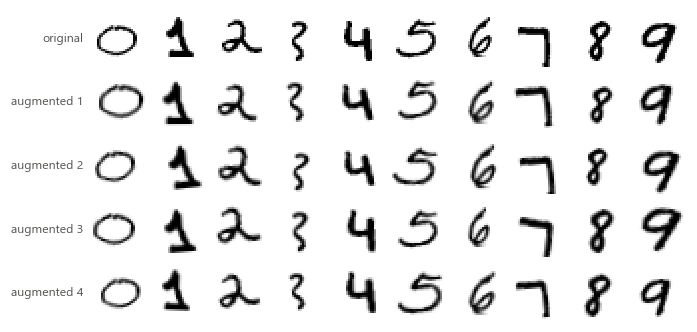

In [11]:
# Figure: ten training digits (top row) and four random augmentations of each
torch.manual_seed(0)
idx = [int(np.flatnonzero(y_tr_np == d)[0]) for d in range(10)]
orig = x_train[idx]
rows = [orig] + [random_augment(orig) for _ in range(4)]
fig, axes = plt.subplots(5, 10, figsize=(7.0, 3.7))
for r, batch in enumerate(rows):
    for c in range(10):
        show_img(axes[r, c], batch[c, 0].cpu())
    axes[r, 0].set_ylabel("original" if r == 0 else f"augmented {r}", rotation=0, ha="right", va="center",
                          fontsize=8, color=INK2)
fig.subplots_adjust(wspace=0.08, hspace=0.08)
save_fig(fig, "fig_augmentation")
plt.show()

## 2. Model architecture

In [12]:
BASELINE = Config(arch="simple", dropout=0.5, augment=False)                      # template-style CNN
model_main = build_model(MAIN).to(DEVICE)
model_base = build_model(BASELINE).to(DEVICE)


def layer_table(model):
    """Output shape and parameter count of each top-level stage (collected with forward hooks)."""
    rows, hooks = [], []
    for name, mod in model.named_children():
        if name == "standardize":
            continue
        hooks.append(mod.register_forward_hook(
            lambda m, i, o, name=name: rows.append(
                (name, type(m).__name__, "×".join(map(str, o.shape[1:])), sum(p.numel() for p in m.parameters())))))
    model.eval()
    with torch.no_grad():
        model(torch.zeros(1, 1, 28, 28, device=DEVICE))
    for h in hooks:
        h.remove()
    return pd.DataFrame(rows, columns=["stage", "type", "output shape", "parameters"]).set_index("stage")


print(model_main)
lt_main, lt_base = layer_table(model_main), layer_table(model_base)
save_table(lt_main, "layers_digitnet"); save_table(lt_base, "layers_simplecnn")
display(lt_main); display(lt_base)

complexity = {}
for label, m in [("DigitNet", model_main), ("SimpleCNN", model_base)]:
    n_par = sum(p.numel() for p in m.parameters())
    complexity[label] = {
        "parameters": n_par,
        "MACs per image": count_macs(m),
        "size (MB, fp32)": n_par * 4 / 2**20,
        "conv layers (k>1)": sum(isinstance(x, nn.Conv2d) and x.kernel_size[0] > 1 for x in m.modules()),
        "1x1 shortcut convs": sum(isinstance(x, nn.Conv2d) and x.kernel_size[0] == 1 for x in m.modules()),
        "FC layers (head)": sum(isinstance(x, nn.Linear) for x in m.head.modules()),
    }
complexity_df = pd.DataFrame(complexity).T
SUMMARY["complexity"] = df_json(complexity_df)
save_table(complexity_df, "complexity")
display(complexity_df)

DigitNet(
  (standardize): Standardize()
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (block1): ResidualSEBlock(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): SqueezeExcite(
      (fc1): Linear(in_features=32, out_features=4, bias=True)
      (fc2): Linear(in_features=4, out_features=32, bias=True)
    )
    (shortcut): Identity()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (block2): ResidualSEBlock(
    (conv1): Conv2d(32, 64, kernel

,type,output shape,parameters
stage,,,
stem,Sequential,32×28×28,864
block1,ResidualSEBlock,32×28×28,18852
pool1,MaxPool2d,32×14×14,0
block2,ResidualSEBlock,64×14×14,58824
pool2,MaxPool2d,64×7×7,0
block3,ResidualSEBlock,128×7×7,234384
gap,AdaptiveAvgPool2d,128×1×1,0
head,Sequential,10,17802


,type,output shape,parameters
stage,,,
conv1,Conv2d,32×28×28,832
conv2,Conv2d,64×14×14,51264
head,Sequential,10,402826


,parameters,MACs per image,"size (MB, fp32)",conv layers (k>1),1x1 shortcut convs,FC layers (head)
DigitNet,330726.0,3.7580e+07,1.2616,7.0,2.0,2.0
SimpleCNN,454922.0,1.1065e+07,1.7354,2.0,0.0,2.0


## 3. Training

In [13]:
display(pd.Series(asdict(MAIN), name="value").to_frame())

,value
arch,digitnet
dropout,0.3
augment,True
lr,0.001
batch_size,128
weight_decay,0.01
max_epochs,50
es_patience,10
sched_factor,0.5
sched_patience,2


In [14]:
# Train the main model (seed 0). One line per epoch; if the run is cached it is loaded instead.
main_model, main_rec = fit(MAIN, verbose=True)
hist = pd.DataFrame(main_rec["history"]).set_index("epoch")
best_ep, stop_ep = main_rec["best_epoch"], main_rec["stopped_epoch"]
print(f"\nbest validation loss at epoch {best_ep}; training stopped at epoch {stop_ep} "
      f"({'early stopping' if main_rec['early_stopped'] else 'max epochs'}); "
      f"training time {main_rec['train_time_s']:.0f} s ({hist['epoch_time'].mean():.2f} s per epoch)")
SUMMARY["main_training"] = {k: main_rec[k] for k in
                            ["best_epoch", "stopped_epoch", "early_stopped", "train_time_s", "n_params"]}
SUMMARY["main_training"]["mean_epoch_time_s"] = float(hist["epoch_time"].mean())
SUMMARY["main_training"]["history"] = main_rec["history"]
save_table(hist, "main_history")
display(hist.round(5))

[cache] main_s0: best epoch 26/36, test acc 99.70%

best validation loss at epoch 26; training stopped at epoch 36 (early stopping); training time 113 s (3.00 s per epoch)


,lr,train_loss,train_acc,train_clean_loss,train_clean_acc,val_loss,val_acc,test_loss,test_acc,weight_norm,epoch_time
epoch,,,,,,,,,,,
1,1.0000e-03,0.3170,0.9070,0.2184,0.9339,0.2323,0.9314,0.2195,0.9350,24.2692,3.8359
2,1.0000e-03,0.0730,0.9784,0.0623,0.9816,0.0728,0.9800,0.0470,0.9857,26.3565,3.3507
3,1.0000e-03,0.0573,0.9830,0.0505,0.9849,0.0609,0.9830,0.0478,0.9859,28.0742,3.1060
4,1.0000e-03,0.0468,0.9863,0.0559,0.9840,0.0700,0.9818,0.0543,0.9838,29.6039,3.0162
5,1.0000e-03,0.0404,0.9879,0.0266,0.9917,0.0367,0.9906,0.0222,0.9926,31.1737,2.9894
6,1.0000e-03,0.0397,0.9891,0.0336,0.9893,0.0390,0.9890,0.0358,0.9895,32.5173,2.8079
7,1.0000e-03,0.0352,0.9894,0.0296,0.9909,0.0398,0.9896,0.0260,0.9921,33.8486,2.8128
8,1.0000e-03,0.0333,0.9906,0.0223,0.9929,0.0259,0.9928,0.0227,0.9925,35.1026,2.7631
9,1.0000e-03,0.0320,0.9906,0.0203,0.9931,0.0306,0.9910,0.0268,0.9924,36.3474,2.7469


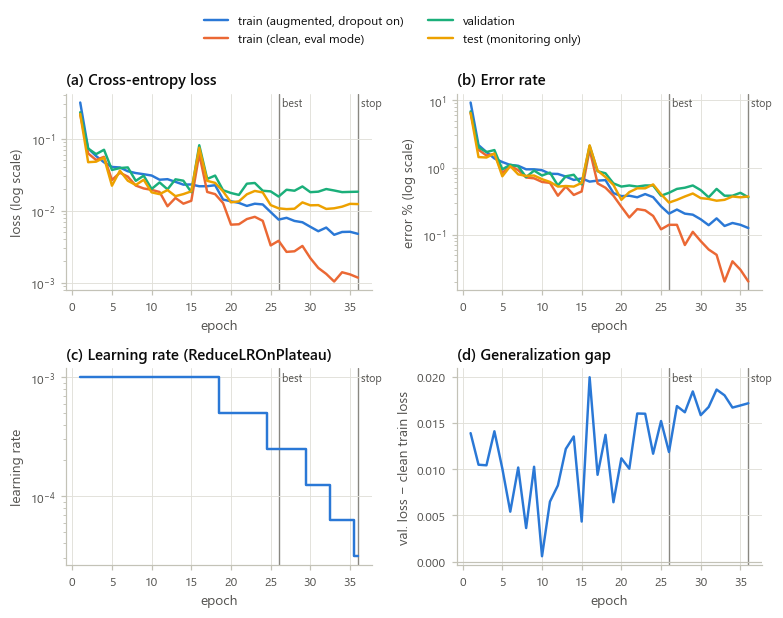

In [15]:
# Figure: learning curves of the main model
def mark_epochs(ax, best, stop):
    """Thin vertical guides at the restored (best-validation) epoch and the stopping epoch."""
    ax.axvline(best, color=MUTED, lw=0.9, zorder=0)
    ax.text(best, 0.98, " best", transform=ax.get_xaxis_transform(), color=INK2, fontsize=7, va="top")
    if stop != best:
        ax.axvline(stop, color=MUTED, lw=0.9, zorder=0)
        ax.text(stop, 0.98, " stop", transform=ax.get_xaxis_transform(), color=INK2, fontsize=7, va="top")


ep = hist.index.values
SERIES = [("train (augmented, dropout on)", "train_loss", "train_acc"),
          ("train (clean, eval mode)", "train_clean_loss", "train_clean_acc"),
          ("validation", "val_loss", "val_acc"),
          ("test (monitoring only)", "test_loss", "test_acc")]
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.4))
ax = axes[0, 0]
for (label, lk, _), col in zip(SERIES, PALETTE):
    ax.plot(ep, hist[lk], color=col, label=label)
ax.set_yscale("log"); ax.set_title("(a) Cross-entropy loss"); ax.set_ylabel("loss (log scale)")
ax = axes[0, 1]
for (label, _, ak), col in zip(SERIES, PALETTE):
    ax.plot(ep, np.maximum(100 * (1 - hist[ak]), 1e-3), color=col, label=label)
ax.set_yscale("log"); ax.set_title("(b) Error rate"); ax.set_ylabel("error % (log scale)")
ax = axes[1, 0]
ax.step(ep, hist["lr"], where="mid", color=PALETTE[0])
ax.set_yscale("log"); ax.set_title("(c) Learning rate (ReduceLROnPlateau)"); ax.set_ylabel("learning rate")
ax = axes[1, 1]
ax.plot(ep, hist["val_loss"] - hist["train_clean_loss"], color=PALETTE[0])
ax.axhline(0, color=AXIS, lw=0.8)
ax.set_title("(d) Generalization gap"); ax.set_ylabel("val. loss − clean train loss")
for a in axes.flat:
    a.set_xlabel("epoch")
    mark_epochs(a, best_ep, stop_ep)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.04))
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "fig_training_curves")
plt.show()

## 4. Test-set evaluation

In [16]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

probs_main = predict_proba(main_model, x_test)
pred_main = probs_main.argmax(1)
metrics_main = classification_metrics(y_test_np, probs_main)
ci_main = bootstrap_ci(y_test_np, pred_main)
SUMMARY["test_metrics_main"] = {**metrics_main, **ci_main}

LABELS = {"accuracy": "accuracy", "n_errors": "errors (of 10,000)", "macro_precision": "macro precision",
          "macro_recall": "macro recall", "macro_f1": "macro F1", "weighted_f1": "weighted F1",
          "cohen_kappa": "Cohen's kappa", "mcc": "Matthews correlation coefficient",
          "roc_auc_ovr_macro": "ROC-AUC (one-vs-rest, macro)", "log_loss": "log-loss (NLL)",
          "top2_accuracy": "top-2 accuracy", "top3_accuracy": "top-3 accuracy",
          "ece": "expected calibration error (15 bins)"}
metrics_df = pd.DataFrame({"value": [metrics_main[k] for k in LABELS]}, index=list(LABELS.values()))
save_table(metrics_df, "test_metrics_main")
display(metrics_df)
print(f"95% bootstrap CI (2,000 resamples): accuracy [{100 * ci_main['accuracy_ci95'][0]:.2f}%, "
      f"{100 * ci_main['accuracy_ci95'][1]:.2f}%], macro-F1 [{ci_main['macro_f1_ci95'][0]:.4f}, "
      f"{ci_main['macro_f1_ci95'][1]:.4f}]")

,value
accuracy,0.9970
"errors (of 10,000)",30.0000
macro precision,0.9970
macro recall,0.9970
macro F1,0.9970
weighted F1,0.9970
Cohen's kappa,0.9967
Matthews correlation coefficient,0.9967
"ROC-AUC (one-vs-rest, macro)",1.0000
log-loss (NLL),0.0108


95% bootstrap CI (2,000 resamples): accuracy [99.59%, 99.80%], macro-F1 [0.9959, 0.9980]


In [17]:
# Per-class precision / recall / F1 and the most frequent confusions
cm = confusion_matrix(y_test_np, pred_main, labels=range(10))
p, r, f1, s = precision_recall_fscore_support(y_test_np, pred_main, labels=range(10), zero_division=0)
per_class = pd.DataFrame({"precision": p, "recall": r, "F1": f1, "support": s,
                          "missed (FN)": s - np.diag(cm), "false alarms (FP)": cm.sum(0) - np.diag(cm)},
                         index=pd.Index([str(d) for d in range(10)], name="digit"))
SUMMARY["per_class"] = df_json(per_class)
save_table(per_class, "per_class_main")
display(per_class)
ranked = per_class.sort_values(["F1", "support"], ascending=[False, True])
print("highest F1:", ", ".join(f"{d} ({v:.4f})" for d, v in ranked["F1"].head(3).items()))
print("lowest  F1:", ", ".join(f"{d} ({v:.4f})" for d, v in ranked["F1"].tail(3)[::-1].items()))

pairs_df = (pd.DataFrame([(t, q, cm[t, q]) for t in range(10) for q in range(10) if t != q and cm[t, q] > 0],
                         columns=["true", "predicted", "count"])
            .sort_values("count", ascending=False).reset_index(drop=True))
undirected = {}
for t, q, c in pairs_df.itertuples(index=False):
    key = f"{min(t, q)}↔{max(t, q)}"
    undirected[key] = undirected.get(key, 0) + int(c)
undirected = pd.Series(undirected, name="errors").sort_values(ascending=False)
SUMMARY["confusions_directed"] = pairs_df.head(15).to_dict(orient="records")
SUMMARY["confusions_undirected"] = undirected.head(10).to_dict()
save_table(pairs_df, "confusion_pairs")
print("\nmost frequent directed confusions (true → predicted):")
display(pairs_df.head(10).T)
print("most frequent confusion pairs (both directions):")
display(undirected.head(8).to_frame().T)

,precision,recall,F1,support,missed (FN),false alarms (FP)
digit,,,,,,
0,0.9980,0.9990,0.9985,980,1,2
1,0.9974,0.9991,0.9982,1135,1,3
2,0.9961,0.9971,0.9966,1032,3,4
3,0.9970,0.9970,0.9970,1010,3,3
4,0.9939,0.9990,0.9964,982,1,6
5,0.9966,0.9955,0.9961,892,4,3
6,0.9990,0.9948,0.9969,958,5,1
7,0.9951,0.9961,0.9956,1028,4,5
8,0.9990,0.9969,0.9979,974,3,1


highest F1: 0 (0.9985), 1 (0.9982), 8 (0.9979)
lowest  F1: 7 (0.9956), 5 (0.9961), 4 (0.9964)

most frequent directed confusions (true → predicted):


,0,1,2,3,4,5,6,7,8,9
true,9,5,2,7,6,6,8,3,0,5
predicted,4,3,7,2,0,1,2,5,7,6
count,5,3,3,2,2,2,2,2,1,1


most frequent confusion pairs (both directions):


,4↔9,3↔5,2↔7,0↔6,1↔6,2↔8,1↔7,0↔7
errors,6,5,5,2,2,2,2,1


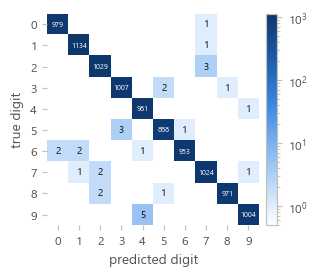

In [18]:
# Figure: confusion matrix (log color scale)
fig, ax = plt.subplots(figsize=(3.0, 2.6))
cmap = seq_cmap().copy(); cmap.set_bad("white")
im = ax.imshow(np.ma.masked_equal(cm, 0), cmap=cmap, norm=LogNorm(vmin=0.5, vmax=cm.max()))   # vmin < 1 so single errors are tinted
for t in range(10):
    for q in range(10):
        if cm[t, q]:
            dark = cm[t, q] > 60
            ax.text(q, t, cm[t, q], ha="center", va="center", fontsize=4.8 if t == q else 6.5,
                    color="white" if dark else INK)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
ax.set_xticks(range(10)); ax.set_yticks(range(10)); ax.grid(False)
ax.set_xlabel("predicted digit"); ax.set_ylabel("true digit")
for sp in ax.spines.values():
    sp.set_visible(False)
fig.tight_layout()
save_fig(fig, "fig_confusion_matrix")
plt.show()

30 errors; for 97% of them the true digit is the model's 2nd choice


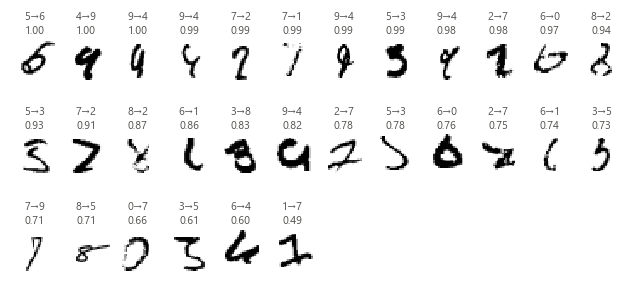

In [19]:
# Figure: every misclassified test digit, most confident mistakes first
wrong = np.flatnonzero(pred_main != y_test_np)
wrong = wrong[np.argsort(-probs_main[wrong].max(1))]
second_right = np.mean(np.argsort(-probs_main[wrong], 1)[:, 1] == y_test_np[wrong]) if len(wrong) else 0
print(f"{len(wrong)} errors; for {100 * second_right:.0f}% of them the true digit is the model's 2nd choice")
SUMMARY["errors_true_is_second_choice"] = float(second_right)
n_show, ncol = min(len(wrong), 48), 12
nrow = max(1, int(np.ceil(n_show / ncol)))
fig, axes = plt.subplots(nrow, ncol, figsize=(7.2, 0.95 * nrow + 0.1))
for k, ax in enumerate(np.atleast_1d(axes).flat):
    if k < n_show:
        i = wrong[k]
        show_img(ax, x_test[i, 0].cpu(), title=f"{y_test_np[i]}→{pred_main[i]}\n{probs_main[i].max():.2f}")
    else:
        ax.axis("off")
fig.subplots_adjust(wspace=0.1, hspace=0.6)
save_fig(fig, "fig_misclassified")
plt.show()

## 5. Overfitting / underfitting

In [20]:
b = best_ep - 1                        # 0-based row of the restored epoch
gap_tbl = pd.DataFrame({
    "loss": [hist.train_loss.iloc[b], hist.train_clean_loss.iloc[b], hist.val_loss.iloc[b], hist.test_loss.iloc[b]],
    "accuracy": [hist.train_acc.iloc[b], hist.train_clean_acc.iloc[b], hist.val_acc.iloc[b], hist.test_acc.iloc[b]],
}, index=["train (augmented, dropout on)", "train (clean, eval mode)", "validation", "test"])
save_table(gap_tbl, "gap_main")
display(gap_tbl)
SUMMARY["fit_main"] = {
    "best_epoch": best_ep, "stopped_epoch": stop_ep,
    "val_loss_min_epoch": int(hist.val_loss.idxmin()), "test_loss_min_epoch": int(hist.test_loss.idxmin()),
    "gap_val_minus_clean_train_at_best": float(hist.val_loss.iloc[b] - hist.train_clean_loss.iloc[b]),
    "gap_test_minus_clean_train_at_best": float(hist.test_loss.iloc[b] - hist.train_clean_loss.iloc[b]),
    "table": df_json(gap_tbl),
}
print(f"validation loss minimum at epoch {hist.val_loss.idxmin()}, test loss minimum at epoch "
      f"{hist.test_loss.idxmin()}, early stopping triggered at epoch {stop_ep}")

,loss,accuracy
"train (augmented, dropout on)",0.0075,0.9979
"train (clean, eval mode)",0.0038,0.9986
validation,0.0157,0.9958
test,0.0108,0.9970


validation loss minimum at epoch 26, test loss minimum at epoch 27, early stopping triggered at epoch 36


,epochs,min val loss epoch,min val loss,final val loss,final clean train loss,final gap (val − train),test acc @ min val loss,test acc @ last epoch
run,,,,,,,,
"DigitNet, all regularization (early-stopped)",36,26,0.0157,0.0183,1.1732e-03,0.0171,0.9970,0.9963
"DigitNet, no regularization",50,23,0.0280,0.0287,3.8691e-06,0.0287,0.9950,0.9954
"SimpleCNN, no regularization",50,7,0.0337,0.0546,1.7435e-05,0.0546,0.9929,0.9938


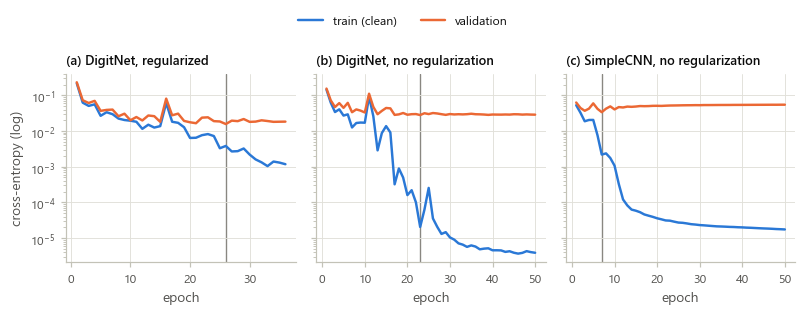

In [21]:
NO_REG = replace(MAIN, dropout=0.0, weight_decay=0.0, augment=False, es_patience=0)
BASELINE_NOREG = Config(arch="simple", dropout=0.0, weight_decay=0.0, augment=False, es_patience=0)
of_records = run_many([NO_REG, BASELINE_NOREG])

of_runs = [("DigitNet, all regularization (early-stopped)", main_rec),
           ("DigitNet, no regularization", of_records[run_name(NO_REG)]),
           ("SimpleCNN, no regularization", of_records[run_name(BASELINE_NOREG)])]
rows = []
for label, rec in of_runs:
    h = rec["history"]
    k = int(np.argmin(h["val_loss"]))
    rows.append({"run": label, "epochs": len(h["val_loss"]), "min val loss epoch": k + 1,
                 "min val loss": h["val_loss"][k], "final val loss": h["val_loss"][-1],
                 "final clean train loss": h["train_clean_loss"][-1],
                 "final gap (val − train)": h["val_loss"][-1] - h["train_clean_loss"][-1],
                 "test acc @ min val loss": h["test_acc"][k], "test acc @ last epoch": h["test_acc"][-1]})
of_df = pd.DataFrame(rows).set_index("run")
SUMMARY["overfitting_runs"] = df_json(of_df)
save_table(of_df, "overfitting_runs")
display(of_df)

PANEL = {of_runs[0][0]: "(a) DigitNet, regularized", of_runs[1][0]: "(b) DigitNet, no regularization",
         of_runs[2][0]: "(c) SimpleCNN, no regularization"}
fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.7), sharey=True)
for ax, (label, rec) in zip(axes, of_runs):
    h = rec["history"]
    e = np.arange(1, len(h["val_loss"]) + 1)
    ax.plot(e, h["train_clean_loss"], color=PALETTE[0], label="train (clean)")
    ax.plot(e, h["val_loss"], color=PALETTE[1], label="validation")
    ax.axvline(int(np.argmin(h["val_loss"])) + 1, color=MUTED, lw=0.9, zorder=0)
    ax.set_yscale("log"); ax.set_xlabel("epoch")
    ax.set_title(PANEL[label], fontsize=8.5)
axes[0].set_ylabel("cross-entropy (log)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06))
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_fig(fig, "fig_overfitting")
plt.show()

## 6. Filters and feature maps

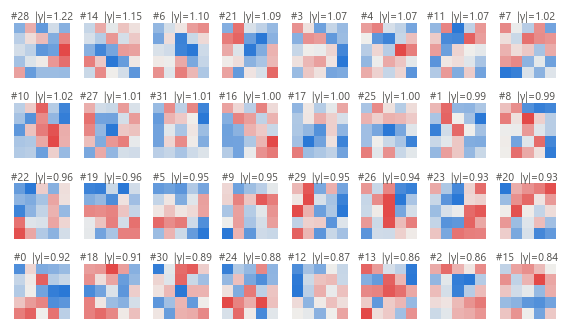

In [22]:
# Figure: conv layer 1 filters (raw 5x5 weights), ordered by the magnitude of their BatchNorm scale
w1 = main_model.first_conv().weight.detach().cpu()[:, 0]          # (32, 5, 5)
gamma1 = main_model.stem[1].weight.detach().abs().cpu().numpy()   # BN scale = how strongly the filter is used
order1 = np.argsort(-gamma1)
fig, axes = plt.subplots(4, 8, figsize=(6.4, 3.5))
for k, ax in enumerate(axes.flat):
    f = order1[k]
    v = float(w1[f].abs().max())
    show_img(ax, w1[f], cmap=div_cmap(), vmin=-v, vmax=v, title=f"#{f}  |γ|={gamma1[f]:.2f}")
fig.subplots_adjust(wspace=0.15, hspace=0.45)
save_fig(fig, "fig_conv1_filters")
plt.show()

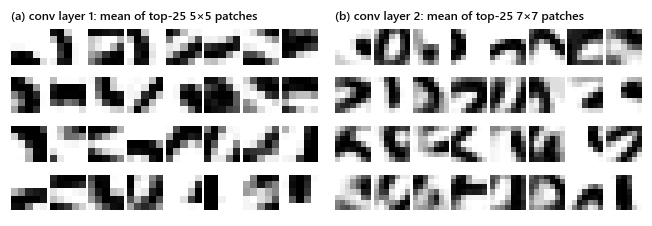

In [23]:
@torch.no_grad()
def top_patch_average(model, act_fn, x, rf, k=25, bs=2000):
    """For every channel returned by act_fn, average the k input patches (rf x rf, centred on the
    location of the channel's maximum response) of the k images that excite it most."""
    vals, pos = [], []
    for i in range(0, len(x), bs):
        a = act_fn(model, x[i:i + bs]).flatten(2)               # (B, C, H*W)
        v, p_ = a.max(-1)
        vals.append(v); pos.append(p_)
    vals, pos = torch.cat(vals), torch.cat(pos)                  # (N, C)
    W = int(round(act_fn(model, x[:1]).shape[-1]))
    half = rf // 2
    xp = F.pad(x, (half, half, half, half))
    out = []
    for c in range(vals.shape[1]):
        top = torch.topk(vals[:, c], k).indices
        patches = [xp[i, 0, r:r + rf, q:q + rf] for i, (r, q) in
                   zip(top.tolist(), [divmod(int(pos[i, c]), W) for i in top.tolist()])]
        out.append(torch.stack(patches).mean(0).cpu())
    return torch.stack(out)


def act_conv1(model, xb):
    return model.stem(model.standardize(xb))                                   # after BN + ReLU


def act_conv2(model, xb):
    z = model.stem(model.standardize(xb))
    return F.relu(model.block1.bn1(model.block1.conv1(z)))                    # after BN + ReLU


patt1 = top_patch_average(main_model, act_conv1, x_test, rf=5)
patt2 = top_patch_average(main_model, act_conv2, x_test, rf=7)
fig, axes = plt.subplots(4, 17, figsize=(7.4, 2.25), gridspec_kw={"width_ratios": [1] * 8 + [0.35] + [1] * 8})
for r in range(4):
    axes[r, 8].axis("off")
    for c in range(8):
        show_img(axes[r, c], patt1[r * 8 + c], cmap="gray_r")
        show_img(axes[r, 9 + c], patt2[r * 8 + c], cmap="gray_r")
axes[0, 0].set_title("(a) conv layer 1: mean of top-25 5×5 patches", loc="left", fontsize=8, pad=6)
axes[0, 9].set_title("(b) conv layer 2: mean of top-25 7×7 patches", loc="left", fontsize=8, pad=6)
fig.subplots_adjust(wspace=0.08, hspace=0.08)
save_fig(fig, "fig_filter_patterns")
plt.show()

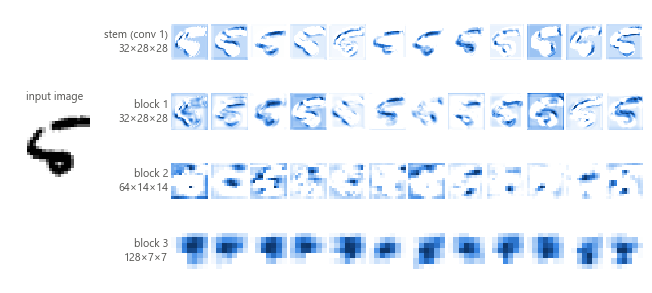

In [24]:
# Figure: feature maps of one test digit at every stage (the 12 most active channels per stage)
i_ex = int(np.flatnonzero((y_test_np == 5) & (pred_main == 5))[0])
with torch.no_grad():
    _, maps_ex = main_model(x_test[i_ex:i_ex + 1], return_maps=True)
stages = [("stem\n(conv 1)", "stem"), ("block 1", "block1"), ("block 2", "block2"), ("block 3", "block3")]
n_show = 12
fig = plt.figure(figsize=(7.4, 3.2))
gs = fig.add_gridspec(4, n_show + 3, width_ratios=[2.4, 0.25, 1.5] + [1] * n_show, wspace=0.08, hspace=0.12)
ax_in = fig.add_subplot(gs[1:3, 0])
show_img(ax_in, x_test[i_ex, 0].cpu(), title="input image")
for r, (label, key) in enumerate(stages):
    fm = maps_ex[key][0].cpu()
    ax_lab = fig.add_subplot(gs[r, 2]); ax_lab.axis("off")          # dedicated column for the row label
    ax_lab.text(1.0, 0.5, f"{label.replace(chr(10), ' ')}\n{fm.shape[0]}×{fm.shape[1]}×{fm.shape[2]}",
                ha="right", va="center", fontsize=7, color=INK2, transform=ax_lab.transAxes)
    top = torch.argsort(fm.mean((1, 2)), descending=True)[:n_show]
    for j, c in enumerate(top.tolist()):
        show_img(fig.add_subplot(gs[r, 3 + j]), fm[c], cmap=seq_cmap())
save_fig(fig, "fig_feature_maps")
plt.show()

In [25]:
# Layer-wise statistics: dead/rarely-active channels and class selectivity of channels
@torch.no_grad()
def layer_stats(model, x, bs=2000):
    """Per channel: fraction of (image, position) pairs with a positive activation, and the
    image-level mean activation (used for class selectivity)."""
    acts = {"conv1 (stem)": [], "conv2 (block1.conv1)": [], "block1": [], "block2": [], "block3": []}
    active = {k: 0 for k in acts}
    for i in range(0, len(x), bs):
        xb = x[i:i + bs]
        _, maps = model(xb, return_maps=True)
        cur = {"conv1 (stem)": maps["stem"], "conv2 (block1.conv1)": act_conv2(model, xb),
               "block1": maps["block1"], "block2": maps["block2"], "block3": maps["block3"]}
        for k, v in cur.items():
            active[k] = active[k] + (v > 0).float().mean((2, 3)).sum(0)
            acts[k].append(v.mean((2, 3)))
    return ({k: (active[k] / len(x)).cpu().numpy() for k in acts},
            {k: torch.cat(v).cpu().numpy() for k, v in acts.items()})


def class_purity(feat, y, top=100):
    """For each channel: share of its top-`top` activating images that belong to its most common class."""
    out, cls = [], []
    for c in range(feat.shape[1]):
        idx = np.argsort(-feat[:, c])[:top]
        cnt = np.bincount(y[idx], minlength=10)
        out.append(cnt.max() / top); cls.append(int(cnt.argmax()))
    return np.array(out), np.array(cls)


active_frac, chan_means = layer_stats(main_model, x_test)
rows = {}
purity = {}
for k in active_frac:
    pur, cls = class_purity(chan_means[k], y_test_np)
    purity[k] = (pur, cls)
    rows[k] = {"channels": len(active_frac[k]),
               "dead (active <1%)": int((active_frac[k] < 0.01).sum()),
               "rarely active (<5%)": int((active_frac[k] < 0.05).sum()),
               "median activity": float(np.median(active_frac[k])),
               "mean class purity (top-100)": float(pur.mean()),
               "channels with purity ≥ 0.9": int((pur >= 0.9).sum())}
layer_df = pd.DataFrame(rows).T
SUMMARY["layer_stats"] = df_json(layer_df)
SUMMARY["conv1_bn_gamma"] = {"min": float(gamma1.min()), "max": float(gamma1.max()),
                             "n_below_0.1": int((gamma1 < 0.1).sum())}
save_table(layer_df, "layer_stats")
display(layer_df)
print("conv1 |BN gamma| (smallest 5):", np.round(np.sort(gamma1)[:5], 3))

,channels,dead (active <1%),rarely active (<5%),median activity,mean class purity (top-100),channels with purity ≥ 0.9
conv1 (stem),32.0,0.0,0.0,0.6596,0.6175,8.0
conv2 (block1.conv1),32.0,0.0,0.0,0.4548,0.6025,5.0
block1,32.0,0.0,0.0,0.6987,0.5672,2.0
block2,64.0,0.0,0.0,0.3798,0.7269,20.0
block3,128.0,0.0,0.0,0.3040,0.8884,86.0


conv1 |BN gamma| (smallest 5): [0.844 0.855 0.864 0.875 0.878]


## 7. Hyperparameter study

In [26]:
SWEEPS = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "batch_size": [32, 64, 128, 256, 512],
    "dropout": [0.0, 0.15, 0.3, 0.5, 0.7],
    "weight_decay": [0.0, 1e-4, 1e-3, 1e-2, 1e-1],
    "sched_factor": [0.1, 0.25, 0.5, 1.0],
    "sched_patience": [1, 2, 4],
}
SWEEP_SEEDS = [0, 1, 2]
sweep_cfgs = {p: {v: [replace(MAIN, **{p: v}, seed=s) for s in SWEEP_SEEDS] for v in vals}
              for p, vals in SWEEPS.items()}
sweep_records = run_many([c for d in sweep_cfgs.values() for cs in d.values() for c in cs])


def at_best(rec, key):
    """Value of a logged quantity at the epoch whose weights were finally used."""
    h = rec["history"][key]
    return h[rec["best_epoch"] - 1] if rec["restored_best"] else h[-1]


rows = []
for p, d in sweep_cfgs.items():
    for v, cfgs in d.items():
        recs = [sweep_records[run_name(c)] for c in cfgs]
        acc = np.array([r["final"]["test_acc"] for r in recs])
        rows.append({
            "hyperparameter": p, "value": v, "default": v == getattr(MAIN, p),
            "test acc mean": acc.mean(), "test acc std": acc.std(ddof=1) if len(acc) > 1 else 0.0,
            "val acc mean": np.mean([r["final"]["val_acc"] for r in recs]),
            "best val loss": np.mean([r["best_val_loss"] for r in recs]),
            "best epoch": np.mean([r["best_epoch"] for r in recs]),
            "epochs run": np.mean([r["stopped_epoch"] for r in recs]),
            "train time (s)": np.mean([r["train_time_s"] for r in recs]),
            "clean train loss": np.mean([at_best(r, "train_clean_loss") for r in recs]),
            "gap (val − train)": np.mean([at_best(r, "val_loss") - at_best(r, "train_clean_loss") for r in recs]),
            "weight norm": np.mean([at_best(r, "weight_norm") for r in recs]),
        })
sweep_df = pd.DataFrame(rows)
save_table(sweep_df.set_index(["hyperparameter", "value"]), "hparam_sweeps")
SUMMARY["hparam_sweeps"] = sweep_df.to_dict(orient="records")
for p in SWEEPS:
    display(sweep_df[sweep_df["hyperparameter"] == p].drop(columns="hyperparameter").set_index("value"))

,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
0.0001,False,0.9952,0.0002,0.9945,0.0185,26.6667,36.6667,210.5234,0.0074,0.0111,21.7586
0.0003,False,0.9956,0.0007,0.9945,0.0164,21.6667,31.6667,221.6721,0.0063,0.0101,24.5395
0.0010,True,0.9963,0.0006,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
0.0030,False,0.9963,0.0006,0.9955,0.0164,17.6667,27.6667,192.9967,0.0063,0.0101,81.7430
0.0100,False,0.9965,0.0004,0.9951,0.0159,26.3333,36.3333,257.5485,0.0043,0.0116,246.5321


,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
32.0,False,0.9975,0.0003,0.9960,0.0139,29.0000,39.0000,887.9948,0.0023,0.0116,72.5301
64.0,False,0.9964,0.0009,0.9953,0.0147,22.0000,32.0000,334.3948,0.0038,0.0109,54.5557
128.0,True,0.9963,0.0006,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
256.0,False,0.9962,0.0008,0.9950,0.0172,24.3333,34.3333,147.9175,0.0031,0.0141,31.9808
512.0,False,0.9959,0.0006,0.9955,0.0155,29.3333,39.3333,134.8663,0.0030,0.0126,27.8845


,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
0.00,False,0.9962,0.0006,0.9948,0.0133,21.6667,31.6667,215.1194,0.0028,0.0104,40.6777
0.15,False,0.9964,0.0004,0.9949,0.0147,24.0000,34.0000,239.3936,0.0030,0.0117,42.1441
0.30,True,0.9963,0.0006,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
0.50,False,0.9960,0.0003,0.9948,0.0190,22.3333,32.3333,225.9212,0.0062,0.0128,41.3796
0.70,False,0.9963,0.0003,0.9953,0.0218,24.3333,34.3333,235.6888,0.0059,0.0159,41.8819


,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
0.0000,False,0.9963,2.5166e-04,0.9959,0.0148,22.3333,32.3333,225.4754,0.0039,0.0109,38.2687
0.0001,False,0.9963,1.0000e-04,0.9963,0.0141,23.0000,33.0000,227.5217,0.0029,0.0112,38.0340
0.0010,False,0.9964,4.7258e-04,0.9959,0.0141,24.6667,34.6667,242.6744,0.0029,0.0112,42.3658
0.0100,True,0.9963,6.0828e-04,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
0.1000,False,0.9964,2.6458e-04,0.9957,0.0143,30.0000,40.0000,280.7535,0.0021,0.0122,29.8116


,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
0.10,False,0.9965,0.0004,0.9952,0.0157,20.6667,30.6667,214.2017,0.0056,0.0101,40.2767
0.25,False,0.9962,0.0002,0.9955,0.0149,17.6667,27.6667,191.8716,0.0066,0.0083,34.6482
0.50,True,0.9963,0.0006,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
1.00,False,0.9948,0.0005,0.9945,0.0190,15.3333,25.3333,176.9028,0.0113,0.0077,43.6706


,default,test acc mean,test acc std,val acc mean,best val loss,best epoch,epochs run,train time (s),clean train loss,gap (val − train),weight norm
value,,,,,,,,,,,
1.0,False,0.9962,0.0006,0.9951,0.0155,18.0000,28.0000,196.4047,0.0055,0.0100,35.1072
2.0,True,0.9963,0.0006,0.9959,0.0145,22.6667,32.6667,181.1236,0.0040,0.0105,42.0597
4.0,False,0.9968,0.0005,0.9959,0.0160,34.0000,43.0000,344.6900,0.0023,0.0137,51.8479


In [27]:
# Epoch time for each batch size, measured in isolation (no other runs sharing the GPU)
bs_time = pd.Series({bs: time_epoch(replace(MAIN, batch_size=bs)) for bs in SWEEPS["batch_size"]},
                    name="seconds per epoch")
bs_time.index.name = "batch size"
SUMMARY["epoch_time_by_batch_size"] = {str(k): float(v) for k, v in bs_time.items()}
save_table(bs_time.to_frame(), "epoch_time_by_batch_size")
display(bs_time.to_frame().T.round(2))

batch size,32,64,128,256,512
seconds per epoch,10.53,5.34,2.75,1.38,0.87


In [28]:
# Short axis titles for the hyper-parameter figures
TITLES = {"lr": "learning rate", "batch_size": "batch size", "dropout": "dropout rate",
          "weight_decay": "weight decay", "sched_factor": "LR-scheduler factor", "sched_patience": "LR-scheduler patience"}

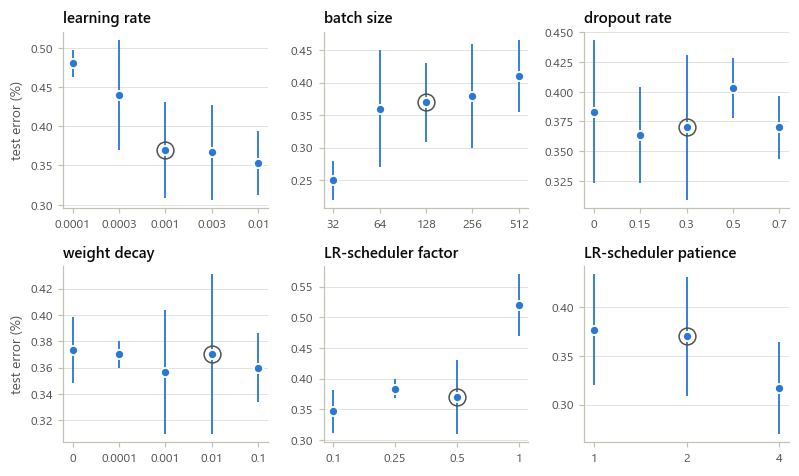

In [29]:
# Figure: test error (mean ± std over seeds) for every hyperparameter value
fig, axes = plt.subplots(2, 3, figsize=(7.4, 4.4))
for ax, p in zip(axes.flat, SWEEPS):
    sub = sweep_df[sweep_df["hyperparameter"] == p]
    xs = np.arange(len(sub))
    err = 100 * (1 - sub["test acc mean"].values)
    ax.errorbar(xs, err, yerr=100 * sub["test acc std"].values, fmt="o", color=PALETTE[0], ecolor=PALETTE[0],
                elinewidth=1.2, capsize=0, markersize=6, markeredgecolor="white", markeredgewidth=1.2)
    dflt = np.flatnonzero(sub["default"].values)
    if len(dflt):
        ax.plot(xs[dflt], err[dflt], "o", markersize=11, markerfacecolor="none", markeredgecolor=INK2, lw=1)
    if err.max() / max(err.min(), 1e-3) > 8:      # a diverged setting would flatten the others -> log axis
        ax.set_yscale("log")
    ax.set_xticks(xs, [f"{v:g}" for v in sub["value"]])
    ax.set_title(TITLES[p]); ax.grid(axis="x", visible=False)
for a in axes[:, 0]:
    a.set_ylabel("test error (%)")
fig.tight_layout()
save_fig(fig, "fig_hparam_summary")
plt.show()

,epochs_trained,restored_epoch,test_acc_mean,test_acc_std
patience,,,,
1,4.0000,3.0000,0.9900,1.6803e-03
2,7.0000,5.0000,0.9914,2.6764e-03
3,11.6667,8.6667,0.9916,3.2021e-03
5,22.0000,17.0000,0.9959,4.5826e-04
7,24.0000,17.0000,0.9959,4.5826e-04
10,32.3333,22.3333,0.9958,5.5076e-04
15,37.3333,22.3333,0.9958,5.5076e-04
20,42.3333,22.3333,0.9958,5.5076e-04
"none (50 epochs, last weights)",50.0000,50.0000,0.9969,5.7735e-05


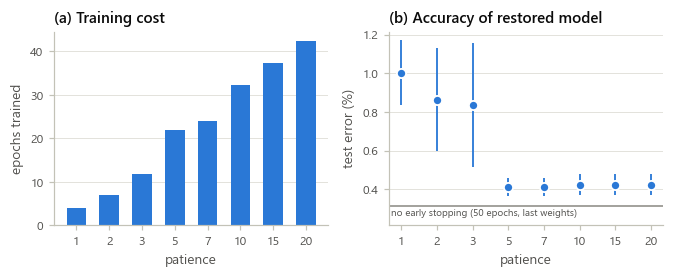

In [30]:
# Early-stopping patience: replay the stopping rule on 50-epoch runs trained without early stopping
LONG = [replace(MAIN, es_patience=0, seed=s) for s in SWEEP_SEEDS]
long_records = run_many(LONG)


def replay_patience(h, patience):
    best, best_ep, counter = np.inf, 0, 0
    for e, v in enumerate(h["val_loss"], start=1):
        if v < best:
            best, best_ep, counter = v, e, 0
        else:
            counter += 1
        if counter >= patience:
            return e, best_ep
    return len(h["val_loss"]), best_ep


PATIENCES = [1, 2, 3, 5, 7, 10, 15, 20]
rows = []
for rec in long_records.values():
    h = rec["history"]
    for pat in PATIENCES:
        stop, best = replay_patience(h, pat)
        rows.append({"patience": pat, "seed": rec["config"]["seed"], "epochs trained": stop,
                     "restored epoch": best, "test acc": h["test_acc"][best - 1]})
    rows.append({"patience": "none (50 epochs, last weights)", "seed": rec["config"]["seed"],
                 "epochs trained": len(h["val_loss"]), "restored epoch": len(h["val_loss"]),
                 "test acc": h["test_acc"][-1]})
pat_raw = pd.DataFrame(rows)
pat_df = pat_raw.groupby("patience", sort=False).agg(
    epochs_trained=("epochs trained", "mean"), restored_epoch=("restored epoch", "mean"),
    test_acc_mean=("test acc", "mean"), test_acc_std=("test acc", "std"))
SUMMARY["patience_replay"] = df_json(pat_df)
save_table(pat_df, "patience_replay")
display(pat_df)

fig, axes = plt.subplots(1, 2, figsize=(6.2, 2.6))
num = pat_df.drop(index="none (50 epochs, last weights)", errors="ignore")
xs = np.arange(len(num))
ax = axes[0]
ax.bar(xs, num["epochs_trained"], width=0.6, color=PALETTE[0])
ax.set_xticks(xs, [str(i) for i in num.index]); ax.set_xlabel("patience"); ax.set_ylabel("epochs trained")
ax.set_title("(a) Training cost"); ax.grid(axis="x", visible=False)
ax = axes[1]
ax.errorbar(xs, 100 * (1 - num["test_acc_mean"]), yerr=100 * num["test_acc_std"].fillna(0), fmt="o",
            color=PALETTE[0], elinewidth=1.2, markersize=6, markeredgecolor="white", markeredgewidth=1.2)
no_es = pat_df.loc["none (50 epochs, last weights)", "test_acc_mean"]
ax.axhline(100 * (1 - no_es), color=MUTED, lw=1)
ax.text(xs[0] - 0.3, 100 * (1 - no_es) - 0.015, "no early stopping (50 epochs, last weights)", ha="left",
        va="top", fontsize=6.5, color=INK2)
ax.set_ylim(bottom=100 * (1 - no_es) - 0.1)
ax.set_xticks(xs, [str(i) for i in num.index]); ax.set_xlabel("patience"); ax.set_ylabel("test error (%)")
ax.set_title("(b) Accuracy of restored model"); ax.grid(axis="x", visible=False)
fig.tight_layout()
save_fig(fig, "fig_patience")
plt.show()

## 8. Baseline comparison

In [31]:
from scipy.stats import binomtest


def mcnemar(pred_a, pred_b, y):
    """Exact McNemar test: do two classifiers make significantly different numbers of errors?"""
    a_only = int(np.sum((pred_a == y) & (pred_b != y)))      # A right, B wrong
    b_only = int(np.sum((pred_a != y) & (pred_b == y)))      # B right, A wrong
    n = a_only + b_only
    return a_only, b_only, (binomtest(min(a_only, b_only), n, 0.5).pvalue if n else 1.0)


BASE_SEEDS = [0, 1, 2]
base_records = run_many([replace(c, seed=s) for c in (MAIN, BASELINE) for s in BASE_SEEDS])
rows = []
for label, cfg in [("DigitNet", MAIN), ("SimpleCNN baseline", BASELINE)]:
    acc = np.array([base_records[run_name(replace(cfg, seed=s))]["final"]["test_acc"] for s in BASE_SEEDS])
    rows.append({"model": label, "test acc mean": acc.mean(),
                 "test acc std": acc.std(ddof=1) if len(acc) > 1 else 0.0, "seeds": len(acc)})
base_df = pd.DataFrame(rows).set_index("model")
SUMMARY["baseline_comparison"] = df_json(base_df)
save_table(base_df, "baseline_comparison")
display(base_df)

,test acc mean,test acc std,seeds
model,,,
DigitNet,0.9963,0.0006,3
SimpleCNN baseline,0.9943,0.0009,3


## 9. Ensembling and test-time augmentation

In [32]:
ENS_SEEDS = [0, 1, 2, 3, 4]
run_many([replace(MAIN, seed=s) for s in ENS_SEEDS])
ens_models = [load_run(replace(MAIN, seed=s))[0] for s in ENS_SEEDS]
ens_probs = [predict_proba(m, x_test) for m in ens_models]
tta_probs = [tta_proba(m, x_test) for m in ens_models]
single = [classification_metrics(y_test_np, pr) for pr in ens_probs]


def summarize(label, pr, cost):
    m_ = classification_metrics(y_test_np, pr)
    return {"method": label, "accuracy": m_["accuracy"], "errors": m_["n_errors"], "macro F1": m_["macro_f1"],
            "log-loss": m_["log_loss"], "ECE": m_["ece"], "forward passes / image": cost}


rows = [{"method": f"single model (mean of {len(ENS_SEEDS)} seeds)",
         "accuracy": np.mean([s_["accuracy"] for s_ in single]), "errors": np.mean([s_["n_errors"] for s_ in single]),
         "macro F1": np.mean([s_["macro_f1"] for s_ in single]), "log-loss": np.mean([s_["log_loss"] for s_ in single]),
         "ECE": np.mean([s_["ece"] for s_ in single]), "forward passes / image": 1},
        summarize("single model, seed 0 (reported model)", ens_probs[0], 1),
        summarize("seed 0 + TTA (5 shifts)", tta_probs[0], 5),
        summarize(f"ensemble of {len(ENS_SEEDS)}", np.mean(ens_probs, 0), len(ENS_SEEDS)),
        summarize(f"ensemble of {len(ENS_SEEDS)} + TTA", np.mean(tta_probs, 0), 5 * len(ENS_SEEDS))]
ens_df = pd.DataFrame(rows).set_index("method")
print("single-model accuracies:", [f"{100 * s_['accuracy']:.2f}%" for s_ in single],
      f"→ mean {100 * np.mean([s_['accuracy'] for s_ in single]):.3f}% ± {100 * np.std([s_['accuracy'] for s_ in single], ddof=1):.3f}")
ens_pred = np.mean(ens_probs, 0).argmax(1)
a_, b_, p_ = mcnemar(ens_pred, pred_main, y_test_np)
print(f"McNemar ensemble vs seed-0 model: ensemble-only correct {a_}, single-only correct {b_}, p = {p_:.4f}")
SUMMARY["ensemble"] = df_json(ens_df)
SUMMARY["ensemble_single_accs"] = [s_["accuracy"] for s_ in single]
SUMMARY["ensemble_mcnemar"] = {"ensemble_only": a_, "single_only": b_, "p": p_}
save_table(ens_df, "ensemble_tta")
display(ens_df)

single-model accuracies: ['99.70%', '99.60%', '99.59%', '99.47%', '99.58%'] → mean 99.588% ± 0.082
McNemar ensemble vs seed-0 model: ensemble-only correct 7, single-only correct 9, p = 0.8036


,accuracy,errors,macro F1,log-loss,ECE,forward passes / image
method,,,,,,
single model (mean of 5 seeds),0.9959,41.2,0.9959,0.0120,0.0020,1
"single model, seed 0 (reported model)",0.9970,30.0,0.9970,0.0108,0.0018,1
seed 0 + TTA (5 shifts),0.9967,33.0,0.9967,0.0095,0.0014,5
ensemble of 5,0.9968,32.0,0.9968,0.0085,0.0015,5
ensemble of 5 + TTA,0.9970,30.0,0.9970,0.0082,0.0010,25


### 9b. Tuned configuration

In [33]:
TUNED = replace(MAIN, batch_size=32, es_patience=0)
TUNED_SEEDS = [0, 1, 2]
tuned_records = run_many([replace(TUNED, seed=s) for s in TUNED_SEEDS])
tuned_models = [load_run(replace(TUNED, seed=s))[0] for s in TUNED_SEEDS]
tuned_probs = [predict_proba(m, x_test) for m in tuned_models]
rows = []
for s, pr in zip(TUNED_SEEDS, tuned_probs):
    rec = tuned_records[run_name(replace(TUNED, seed=s))]
    mt_ = classification_metrics(y_test_np, pr)
    rows.append({"model": f"tuned DigitNet, seed {s}", "val acc": rec["final"]["val_acc"], "test acc": mt_["accuracy"],
                 "errors": mt_["n_errors"], "macro F1": mt_["macro_f1"], "log-loss": mt_["log_loss"]})
mt_ = classification_metrics(y_test_np, np.mean(tuned_probs, 0))
rows.append({"model": f"tuned ensemble of {len(TUNED_SEEDS)}", "val acc": np.nan, "test acc": mt_["accuracy"],
             "errors": mt_["n_errors"], "macro F1": mt_["macro_f1"], "log-loss": mt_["log_loss"]})
tuned_df = pd.DataFrame(rows).set_index("model")
acc_t = tuned_df["test acc"].iloc[:len(TUNED_SEEDS)]
default_accs = [base_records[run_name(replace(MAIN, seed=s))]["final"]["test_acc"] for s in BASE_SEEDS]
print(f"tuned single model : {100 * acc_t.mean():.3f}% ± {100 * acc_t.std(ddof=1) if len(acc_t) > 1 else 0:.3f}")
print(f"default config     : {100 * np.mean(default_accs):.3f}% ± {100 * np.std(default_accs, ddof=1) if len(default_accs) > 1 else 0:.3f}")
a_, b_, p_ = mcnemar(tuned_probs[0].argmax(1), pred_main, y_test_np)
print(f"McNemar tuned seed 0 vs main seed 0: tuned-only correct {a_}, main-only correct {b_}, p = {p_:.3f}")
SUMMARY["tuned"] = {"table": df_json(tuned_df), "mean": float(acc_t.mean()),
                    "std": float(acc_t.std(ddof=1)) if len(acc_t) > 1 else 0.0,
                    "mcnemar_vs_main": {"tuned_only": a_, "main_only": b_, "p": p_}}
save_table(tuned_df, "tuned")
display(tuned_df)

tuned single model : 99.700% ± 0.000
default config     : 99.630% ± 0.061
McNemar tuned seed 0 vs main seed 0: tuned-only correct 11, main-only correct 11, p = 1.000


,val acc,test acc,errors,macro F1,log-loss
model,,,,,
"tuned DigitNet, seed 0",0.9954,0.9970,30,0.9970,0.0107
"tuned DigitNet, seed 1",0.9962,0.9970,30,0.9970,0.0108
"tuned DigitNet, seed 2",0.9964,0.9970,30,0.9970,0.0096
tuned ensemble of 3,NaN,0.9977,23,0.9977,0.0082


## 10. Summary

In [34]:
def to_jsonable(o):
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.floating):
        return float(o)
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    return str(o)


(RESULTS_DIR / "summary.json").write_text(json.dumps(SUMMARY, indent=1, default=to_jsonable))
print(f"DigitNet (seed 0)            : test accuracy {100 * metrics_main['accuracy']:.2f}% "
      f"({metrics_main['n_errors']} errors), macro-F1 {metrics_main['macro_f1']:.4f}")
print(f"DigitNet (3 seeds)           : {100 * base_df.loc['DigitNet', 'test acc mean']:.2f}% ± {100 * base_df.loc['DigitNet', 'test acc std']:.2f}")
print(f"SimpleCNN baseline (3 seeds) : {100 * base_df.loc['SimpleCNN baseline', 'test acc mean']:.2f}%")
print(f"Ensemble of {len(ENS_SEEDS)} + TTA        : {100 * ens_df['accuracy'].iloc[-1]:.2f}%")
print(f"Tuned DigitNet (3 seeds)     : {100 * SUMMARY['tuned']['mean']:.2f}% ± {100 * SUMMARY['tuned']['std']:.2f}")

DigitNet (seed 0)            : test accuracy 99.70% (30 errors), macro-F1 0.9970
DigitNet (3 seeds)           : 99.63% ± 0.06
SimpleCNN baseline (3 seeds) : 99.43%
Ensemble of 5 + TTA        : 99.70%
Tuned DigitNet (3 seeds)     : 99.70% ± 0.00
